In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cmdstanpy import CmdStanModel

import arviz as az

C:\Users\Josh\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Get data
data = pd.read_csv('data/response_times.csv', header=0, sep=';')
data.head()

# Prepare data in Stan friendly format
data_dict = {
    'N': data.shape[0],
    'J': len(set(data.id.values)),
    'id': data.id.values,
    'y': data.rt.values,
    'condition': data.condition.values,
    'choice': data.choice.values
}

# Compile model
model = CmdStanModel(stan_file="diffusion_multiple.stan")

02:45:48 - cmdstanpy - INFO - compiling stan file C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\hw_3\diffusion_multiple.stan to exe file C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\hw_3\diffusion_multiple.exe
02:46:32 - cmdstanpy - INFO - compiled model executable: C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\hw_3\diffusion_multiple.exe


The parameter that best reflects the task difficulty is the drift rate,
because the drift rate is the rate of information accumulation. The faster information
is gotten, the faster it reaches a threshold to make a decision.

In [10]:
# Sample (i.e., inverse inference)
fit = model.sample(data=data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

02:48:17 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 1:   0%|          | 1/3500 [00:00<09:59,  5.84it/s, (Warmup)]




chain 1:   3%|▎         | 100/3500 [00:09<05:08, 11.04it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [00:14<03:41, 14.91it/s, (Warmup)]

chain 1:   9%|▊         | 300/3500 [00:17<02:51, 18.69it/s, (Warmup)]


chain 1:  11%|█▏        | 400/3500 [00:21<02:18, 22.32it/s, (Warmup)]


chain 1:  14%|█▍        | 500/3500 [00:24<02:06, 23.80it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [00:28<01:54, 25.30it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [00:31<01:41, 27.50it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [00:34<01:32, 29.30it/s, (Warmup)]


chain 1:  26%|██▌       | 900/3500 [00:37<01:25, 30.28it/s, (Warmup)]




chain 1:  29%|██▊       | 1000/3500 [00:40<01:22, 30.22it/s, (Sampling)]


chain 1:  31%|███▏      | 1100/3500 [00:43<01:19, 30.04it/s, (Sampling)]



chain 1:  3


02:50:21 - cmdstanpy - INFO - CmdStan done processing.
02:50:21 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: wiener_lpdf: Boundary separation is 0, but must be positive finite! (in 'diffusion_multiple.stan', line 60, column 16 to column 81)
Exception: wiener_lpdf: Boundary separation is inf, but must be positive finite! (in 'diffusion_multiple.stan', line 62, column 16 to column 84)
	Exception: wiener_lpdf: Boundary separation is inf, but must be positive finite! (in 'diffusion_multiple.stan', line 62, column 16 to column 84)
	Exception: wiener_lpdf: Boundary separation is inf, but must be positive finite! (in 'diffusion_multiple.stan', line 62, column 16 to column 84)
	Exception: wiener_lpdf: Boundary separation is inf, but must be positive finite! (in 'diffusion_multiple.stan', line 60, column 16 to column 81)
	Exception: wiener_lpdf: Boundary separation is 0, but must be positive finite! (in 'diffusion_multiple.stan', line 62, column 16 to column 84)
Exceptio

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,-104.133000,0.054940,3.490220,3.385310,-110.300000,-103.860000,-98.953500,4125.34,5641.91,12.9369,1.000410
v_cond1[1],0.768270,0.001613,0.149910,0.148727,0.524091,0.766488,1.021670,8786.64,7063.72,27.5544,1.000580
v_cond1[2],0.628063,0.001747,0.193147,0.191588,0.305708,0.630483,0.946881,12275.40,8671.62,38.4950,1.000170
v_cond1[3],0.570227,0.001849,0.210682,0.210717,0.226436,0.570071,0.911511,13028.80,7935.68,40.8575,1.000050
v_cond1[4],0.394121,0.001891,0.196304,0.198933,0.080851,0.390613,0.718050,10874.10,8597.37,34.1007,1.000380
v_cond1[5],0.184451,0.001954,0.205188,0.200504,-0.155706,0.184312,0.521542,11142.20,8149.91,34.9414,1.000020
v_cond2[1],3.282580,0.002767,0.292921,0.291529,2.802680,3.286690,3.761940,11283.60,7864.87,35.3848,1.000980
v_cond2[2],3.334290,0.003231,0.376136,0.378286,2.710970,3.332000,3.944530,13670.30,8252.56,42.8692,0.999960
v_cond2[3],2.986890,0.003288,0.373377,0.373947,2.369760,2.982370,3.603720,12950.80,8306.85,40.6131,1.000310
v_cond2[4],2.970470,0.003424,0.367533,0.366056,2.381060,2.967900,3.581390,11554.70,7717.94,36.2349,1.000330


,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,tau_raw[1],tau_raw[2],tau_raw[3],tau_raw[4],tau_raw[5],tau[1],tau[2],tau[3],tau[4],tau[5]
0,1.0,1.0,1.0,-103.93593,0.918828,0.258915,4.0,15.0,0.0,121.40626,...,0.645592,0.952077,0.945456,0.910930,0.890085,0.335449,0.405203,0.402007,0.410738,0.278596
1,1.0,2.0,2.0,-109.52451,0.978335,0.258915,4.0,15.0,0.0,119.26016,...,0.663917,0.928285,0.902088,0.922919,0.865477,0.344970,0.395077,0.383567,0.416143,0.270893
2,1.0,3.0,3.0,-105.00475,0.997011,0.258915,4.0,15.0,0.0,121.18735,...,0.747377,0.892160,0.957431,0.888837,0.918452,0.388336,0.379702,0.407099,0.400776,0.287475
3,1.0,4.0,4.0,-101.83696,0.532560,0.258915,4.0,15.0,0.0,124.31294,...,0.762780,0.887840,0.966067,0.931808,0.852649,0.396340,0.377864,0.410771,0.420151,0.266878
4,1.0,5.0,5.0,-102.38095,0.841484,0.258915,4.0,15.0,0.0,118.94954,...,0.792897,0.918639,0.900685,0.938291,0.842287,0.411989,0.390972,0.382970,0.423075,0.263635


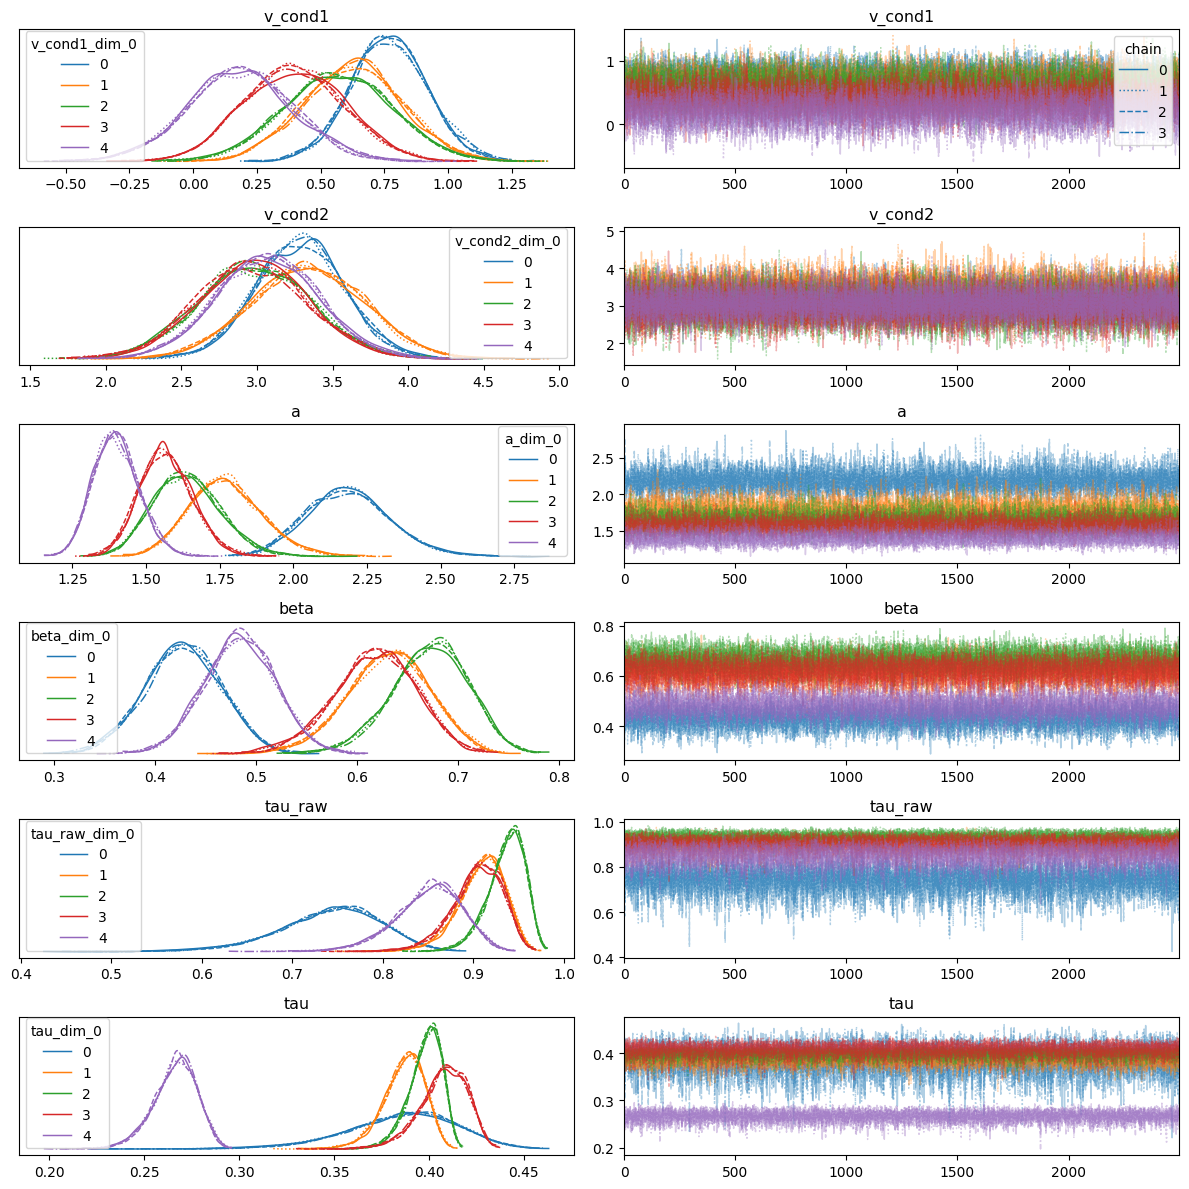

In [24]:
# Display sampling data
summary = fit.summary()
display(summary)

draws_df = fit.draws_pd()
display(draws_df.head())

# Plot
_ = az.plot_trace(fit, legend=True)
plt.tight_layout()

In [ ]:
v_cond1_cols = [col for col in draws_df.columns if col.startswith("v_cond1")]
v_cond2_cols = [col for col in draws_df.columns if col.startswith("v_cond2")]
v_cond1_mean = draws_df[v_cond1_cols].values.mean()
v_cond2_mean = draws_df[v_cond2_cols].values.mean()

print("Condition 1 Mean Drift Rate:", v_cond1_mean)
print("Condition 2 Mean Drift Rate:", v_cond2_mean)

Condition 1 Mean Drift Rate: 0.5090263474817527
Condition 2 Mean Drift Rate: 3.128815723534


The high-interference field corresponds to condition 1, and the low-interference field corresponds to condition 2. 
This is because condition 1 has a lower average drift rate than condition 2, which means that making a decision is more difficult in trials with condition 1.

In [28]:
# Display samping diagnostics
print(fit.diagnose())

# Ensure all R hat values are <=1.01
thresh = 1.01
num = 0
num_past = 0
for r_hat in summary['R_hat']:
    num += 1
    if r_hat > thresh:
        num_past += 1
print("Number of", num, "R Hat Values Past Threshold:", num_past)

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.

Number of 31 R Hat Values Past Threshold: 0


The `diagnose()` function reports that the treedepth is satisfactory, which means it searched efficiently,
and that no divergences were found, which means that it converged properly.
Additionally, all R hat values are below the threshold 1.01, which also means that each parameter converged well.